# Chess Oracle — predicting Titled Tuesday outcomes from rating & title alone

**Outcome:** `loss` / `draw` / `win` from **White's** perspective, on Chess.com
*Titled Tuesday* blitz events. This single notebook tells the whole story of the
project end to end and replaces the two exploratory notebooks it grew out of
(`own_approach.ipynb` and `dirichlet_multinomial_model.ipynb`).

## The story in one paragraph

We let a large language model explore the public Chess.com API, understand it,
propose features, and write the data pipeline. We engineered and tried *dozens*
of features, found that almost none of them helped, and settled on **six** simple
quantities derived from pre-game Elo and player title. We then ran a full model
bake-off — Naive Bayes, Random Forest, Logistic Regression, an ordinal linear
regression, **XGBoost**, and a small **MLP** — and discovered a hard ceiling
around **66% accuracy**, driven almost entirely by the rating gap. Crucially,
**draws turn out to be nearly impossible to predict** from these signals. XGBoost
was our pick among the flexible learners (well-calibrated and SHAP-interpretable,
on par with the MLP on accuracy) — yet the *simplest* models kept right up with
it. We then built a **Bayesian Dirichlet-Multinomial "smart counting" model** that
*matches* XGBoost while being far more interpretable and updatable in `O(1)`. We
close with where this goes next: per-player AI agents built from their game
records (PGNs).

## Roadmap

1. **The data pipeline** — how an LLM explored the API and wrote `build_dataset.py`.
2. **Leakage-safe data & the temporal split** — extra tournaments, last one held out.
3. **EDA** — class balance and *why draws are hard*.
4. **Feature selection** — from 90+ columns down to 6 (and SHAP confirms it).
5. **Model bake-off** — six models, one comparable scoreboard.
6. **A Bayesian alternative** — the Dirichlet-Multinomial counting model, in depth.
7. **Head-to-head** — every model on one table.
8. **Where this goes next** — PGN-based player agents.

> **Audience note.** Part 6 introduces Bayesian ideas from scratch. No prior
> exposure to Bayesian statistics is assumed — every term is defined in plain

> language with a chess-flavoured intuition before any math appears.

## 1. The data pipeline — an LLM that read the API for us

There is no tidy "chess games" dataset for this problem, so we had to build one.
Instead of reverse-engineering the Chess.com API by hand, we handed the job to a
large language model (**Claude Opus 4.8**) and had it:

1. **Explore the public Chess.com API.** Working from a handful of saved sample
   responses (see [`api_output_samples/`](api_output_samples/) —
   `tournament_info.json`, `tournamment_rounds.json`,
   `tournamment_round-group_games.json`, `player_profile.json`,
   `player_stats.json`), the model mapped out the endpoint graph: a *tournament*
   contains *rounds*, each round contains *groups*, and each group lists the
   individual *games*, while separate endpoints return a player's *profile* and
   *rating stats*.
2. **Understand game results.** It worked out how Chess.com encodes outcomes
   (the many result codes that collapse into White-perspective `win` / `loss` /
   `draw`).
3. **Suggest features.** It proposed the signals a chess analyst would reach for
   first — pre-game Elo for both colors, the rating gap, and an ordinal encoding
   of FIDE/Chess.com titles (`GM`=7 … down to untitled=0).
4. **Write the pipeline.** It then programmed [`build_dataset.py`](build_dataset.py),
   which crawls `tournament → rounds → groups → games`, fetches each player's
   profile/stats, caches every raw API response under `data/raw/`, and emits the
   tidy table `data/processed/games.parquet`.

### Leakage was designed out from the start

The subtle trap in sports/game prediction is **target leakage** — accidentally
feeding the model information it would not have *before* the game. Chess ratings
update *after* every game, so naively joining "current rating" would leak the
result. `build_dataset.py` audits the rating field per round and reconstructs a
**lagged, strictly pre-game Elo** for each player. The accompanying
[`DATA_DICTIONARY.md`](DATA_DICTIONARY.md) tags every column by leakage tier
(`FEATURE` = safe / known before the game, vs. `LABEL` / `POST` / `ID`). The six
features we end up using are **all `FEATURE`-tier**.


## Setup & shared utilities

A few imports and — importantly — **two scoring functions defined once and reused
by every model in the notebook**, so that XGBoost, the MLP, and the Bayesian
model are all judged on an identical, comparable basis.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from scipy.special import gammaln, softmax

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, roc_auc_score, log_loss)

%matplotlib inline

# Fixed, natural ORDINAL ordering of the target: loss < draw < win.
OUTCOMES = ["loss", "draw", "win"]
OUTCOME_COLORS = {"loss": "#d62728", "draw": "#7f7f7f", "win": "#2ca02c"}


# --- Canonical proper scoring rules, shared by EVERY model below -------------
# Both expect `probs` with columns in OUTCOMES order and integer true labels in
# the same order. Defining them once guarantees apples-to-apples comparison.
def rps(probs, true_outcome_idx):
    """Ranked Probability Score (lower is better). Respects loss < draw < win."""
    K = probs.shape[1]
    cum_probs = np.cumsum(probs, axis=1)
    true_onehot = np.eye(K)[true_outcome_idx]
    cum_true = np.cumsum(true_onehot, axis=1)
    return ((cum_probs - cum_true) ** 2).sum(axis=1) / (K - 1)


def multiclass_log_loss(probs, true_outcome_idx, eps=1e-12):
    """Per-row negative log-probability of the true class (lower is better)."""
    p = np.clip(probs[np.arange(len(true_outcome_idx)), true_outcome_idx], eps, 1)
    return -np.log(p)

## 2. Leakage-safe data & the temporal split

To get a trustworthy estimate of real-world performance we deliberately
**downloaded more data than we strictly needed**: every Titled Tuesday blitz
event we could across **February, March, and April 2026** (seven tournaments in
all). More events means more players, more rating regimes, and — most
importantly — the ability to hold out an **entire future tournament** as the test
set rather than shuffling games at random.

The held-out set is the **last** tournament chronologically
(`titled-tuesday-blitz-april-14-2026`). Splitting on the tournament id (not at
random) is what prevents leakage: a random split could put one game of a player's
April session in *train* and the next in *test*, leaking their form across the
boundary. A clean forward-in-time hold-out cannot.

In [35]:
df = pd.read_parquet("data/processed/games.parquet")

# The two engineered "gap" features, derived from leakage-safe raw signals.
df["elo_diff"] = df["white_elo"] - df["black_elo"]
df["ordinal_title_differences"] = (
    df["white_title_ordinal"].fillna(0) - df["black_title_ordinal"].fillna(0)
)

FEATURES = ["white_elo", "black_elo", "elo_diff",
            "white_title_ordinal", "black_title_ordinal",
            "ordinal_title_differences"]

# Held-out tournament = the LAST Titled Tuesday we crawled (April 14, 2026).
HELD_OUT = "titled-tuesday-blitz-april-14-2026-6362193"
train_mask = ~df["tournament"].str.contains(HELD_OUT)
test_mask = df["tournament"].str.contains(HELD_OUT)

train = df[train_mask].copy()
test = df[test_mask].copy()

print(f"Full dataset:      {df.shape[0]:>6} games x {df.shape[1]} columns")
print(f"Train (Feb-Apr 7): {train.shape[0]:>6} games")
print(f"Test  (Apr 14):    {test.shape[0]:>6} games")

Full dataset:       12031 games x 98 columns
Train (Feb-Apr 7):  10573 games
Test  (Apr 14):      1458 games


## 3. Exploratory analysis — and why this problem is hard

### 3.1 The class balance is lopsided

White wins a bit more than it loses, and **draws are rare** — under one game in
ten. That scarcity, combined with the fact (shown next) that draws have no clean
"signature" in the features, is the single biggest obstacle in the whole project.

In [36]:
counts = df["outcome"].value_counts()
shares = df["outcome"].value_counts(normalize=True)
pd.DataFrame({"count": counts, "share": shares.round(3)})

,count,share
outcome,,
win,5810,0.483
loss,5141,0.427
draw,1080,0.090


### 3.2 The draw problem, visualized

Below is the most important plot in the notebook. We histogram `elo_diff`
separately for each outcome. If draws were predictable, the **draw** panel would
look distinctly different from the others — concentrated where the players are
evenly matched (`elo_diff ≈ 0`), say. Instead, the draw distribution is just a
smaller, flatter echo of the win/loss panels: **there is no region of feature
space that is characteristically "drawish."** Wins and losses, by contrast,
separate cleanly — wins pile up at positive `elo_diff`, losses at negative.

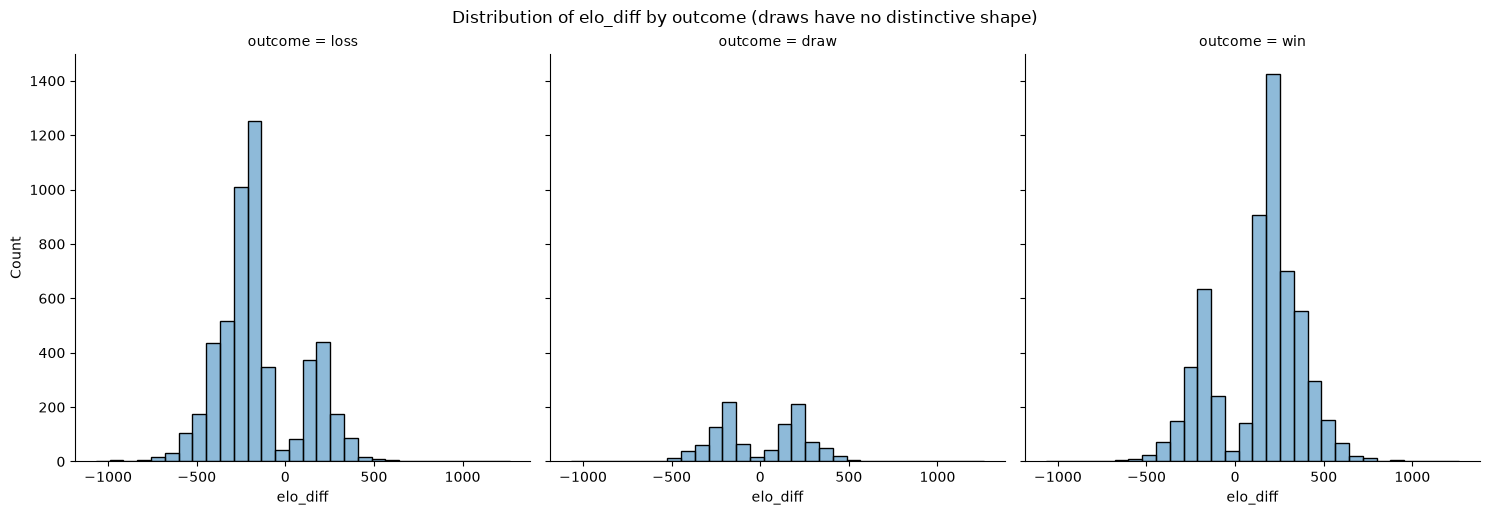

In [37]:
sns.displot(
    data=df,
    x="elo_diff",
    col="outcome",
    col_order=OUTCOMES,
    kde=False,
    bins=30,
    alpha=0.5,
)
plt.suptitle("Distribution of elo_diff by outcome (draws have no distinctive shape)", y=1.02)
plt.show()

### 3.3 How the six features relate to each other

A quick correlation check on the training features. `elo_diff` is, by
construction, strongly tied to `white_elo`/`black_elo`, and
`ordinal_title_differences` to the two title ordinals — so the "gap" features
carry most of the usable signal while the raw levels add a little context.

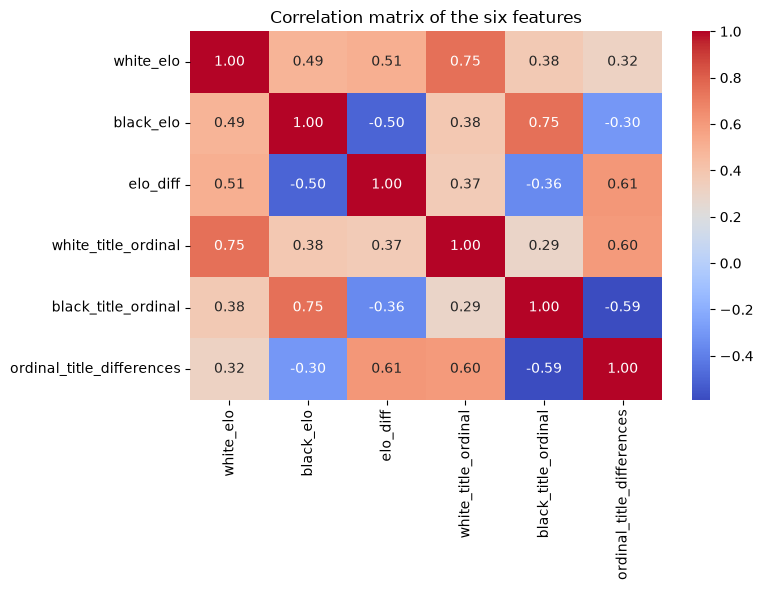

In [38]:
corr_matrix = train[FEATURES].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix of the six features")
plt.tight_layout()
plt.show()

## 4. Feature selection — from 90+ columns down to six

`build_dataset.py` actually emits **~90 columns**: pre-game Elo, FIDE ratings,
title ordinals, account age, follower counts, running tournament score, current
streak, average opponent strength so far, performance-vs-expected, rating
deviation, and more. We did the obvious thing and *tried* them — individually, in
combinations, and as freshly engineered interactions (ratios, absolute mismatch,
mean rating level, FIDE-missingness flags, and so on).

**Almost none of it moved the needle.** Models trained on the kitchen sink scored
within noise of models trained on a tiny handful of rating/title features, and
the extra columns mostly added variance and leakage risk. So we made a deliberate
parsimony call and kept just **six** quantities, every one of which maps to an
idea a chess player would recognize:

| variable | definition | role |
|---|---|---|
| `white_elo`, `black_elo` | leakage-free pre-game Elo of each side | raw skill each player brings |
| `elo_diff` | `white_elo − black_elo` | **the dominant predictor** — the win/loss axis is essentially monotone in it |
| `white_title_ordinal`, `black_title_ordinal` | ordinal title (`GM`=7 … untitled=0) | a slow-moving skill/experience proxy Elo can miss |
| `ordinal_title_differences` | `white_title_ordinal − black_title_ordinal` | does out-titling your opponent matter beyond raw rating? |

We don't just assert this — **SHAP on the XGBoost model (Part 5) confirms it**:
`elo_diff` and the raw Elos dominate the attribution, with the title features a
distant, modest second and everything else negligible.

## 5. The model bake-off

We evaluated a deliberately broad spread of models on the **same split** and the
**same six features**, scored on the **same yardsticks**:

- **Naive Bayes** — the simplest probabilistic baseline.
- **Random Forest** — non-linear, non-parametric ensemble.
- **Logistic Regression** — the canonical linear classifier.
- **Linear Regression** on an *ordinal* mapping `loss = −1, draw = 0, win = +1` —
  a deliberately naive idea, included to show what treating an ordered category
  as a single continuous number does (spoiler: it erases the draw class).
- **XGBoost** — gradient-boosted trees, our tuned front-runner.
- **MLP** — a small neural net, to check whether more flexible function classes help.

**Scoring.** Accuracy alone is misleading on an imbalanced 3-class problem, so we
also report two *proper scoring rules* (both lower-is-better) computed in the
natural ordinal order `loss < draw < win`:

- **RPS** (Ranked Probability Score) — rewards getting the *ordering* right; a
  "predicted win, got draw" hurts less than "predicted win, got loss."
- **Multiclass log loss** — punishes confident wrong answers.
- **AUC for P(draw)** — can the model's draw probability even *rank* draws above
  non-draws? (0.5 = coin flip.)

In [39]:
# One shared label encoding (alphabetical): classes_ = ['draw', 'loss', 'win'].
le = LabelEncoder().fit(df["outcome"])
num_classes = len(le.classes_)


def feature_matrix(d):
    """Six-feature design matrix; title ordinals filled with 0 for untitled players."""
    X = d[FEATURES].copy()
    X["white_title_ordinal"] = X["white_title_ordinal"].fillna(0)
    X["black_title_ordinal"] = X["black_title_ordinal"].fillna(0)
    return X


X_train, X_test = feature_matrix(train), feature_matrix(test)
y_train, y_test = le.transform(train["outcome"]), le.transform(test["outcome"])

# Unified target in OUTCOMES (loss<draw<win) order, used by the shared evaluator.
y_test_outcomes = test["outcome"].map({o: i for i, o in enumerate(OUTCOMES)}).values

model_scores = {}


def evaluate(name, proba, class_order):
    """Score any probabilistic model on one comparable basis (OUTCOMES order)."""
    idx = [list(class_order).index(o) for o in OUTCOMES]
    p = np.asarray(proba)[:, idx]
    draw_i = OUTCOMES.index("draw")
    model_scores[name] = {
        "accuracy": accuracy_score(y_test_outcomes, p.argmax(axis=1)),
        "RPS": rps(p, y_test_outcomes).mean(),
        "log_loss": multiclass_log_loss(p, y_test_outcomes).mean(),
        "AUC_draw": roc_auc_score((y_test_outcomes == draw_i).astype(int), p[:, draw_i]),
    }
    return model_scores[name]


def eval_sklearn(name, clf):
    clf.fit(X_train, y_train)
    return evaluate(name, clf.predict_proba(X_test), le.classes_)

### 5.1 Simple probabilistic baselines

In [40]:
from sklearn.pipeline import make_pipeline

eval_sklearn("Naive Bayes", GaussianNB())
eval_sklearn("Random Forest", RandomForestClassifier(n_estimators=300, random_state=42))
# Scale first so the linear solver converges cleanly on the raw Elo magnitudes.
eval_sklearn("Logistic Regression",
             make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)))

pd.DataFrame(model_scores).T.round(4)

,accuracy,RPS,log_loss,AUC_draw
Naive Bayes,0.6557,0.2228,0.9863,0.5401
Random Forest,0.6296,0.2173,1.0417,0.5230
Logistic Regression,0.6632,0.1953,0.8148,0.5577


### 5.2 The ordinal linear regression

Map the ordered outcome to a single number, fit an ordinary least-squares line,
then snap the continuous prediction back to the nearest of `{-1, 0, +1}`. A
regression line has no calibrated class probabilities, so we can only report
accuracy here — and, tellingly, it predicts **essentially no draws**: collapsing
an ordered category onto one axis pushes the rare middle class out entirely.

In [41]:
lin_map = {"loss": -1, "draw": 0, "win": 1}
y_lin_train = train["outcome"].map(lin_map).values
y_lin_test = test["outcome"].map(lin_map).values

linreg = LinearRegression().fit(X_train, y_lin_train)
pred_cont = linreg.predict(X_test)
pred_class = np.where(pred_cont < -0.5, -1, np.where(pred_cont > 0.5, 1, 0))

lin_acc = accuracy_score(y_lin_test, pred_class)
model_scores["Linear Regression (-1/0/1)"] = {
    "accuracy": lin_acc, "RPS": np.nan, "log_loss": np.nan, "AUC_draw": np.nan,
}
print(f"Linear regression accuracy: {lin_acc:.4f}")
print("Predicted class counts (-1=loss, 0=draw, +1=win):",
      dict(zip(*np.unique(pred_class, return_counts=True))))

Linear regression accuracy: 0.3224
Predicted class counts (-1=loss, 0=draw, +1=win): {np.int64(-1): np.int64(197), np.int64(0): np.int64(981), np.int64(1): np.int64(280)}


### 5.3 The XGBoost Model


In [42]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "multi:softprob",
    "num_class": num_classes,
    "eval_metric": "mlogloss",
    "max_depth": 10,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "seed": 42,
}

evals = [(dtrain, "train"), (dtest, "eval")]
model = xgb.train(params, dtrain, num_boost_round=1000, evals=evals,
                  early_stopping_rounds=50, verbose_eval=50)

[0]	train-mlogloss:0.89879	eval-mlogloss:0.91615
[50]	train-mlogloss:0.54651	eval-mlogloss:0.85397
[69]	train-mlogloss:0.50657	eval-mlogloss:0.86754


In [43]:
y_pred_probs = model.predict(dtest)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))
print("\nConfusion Matrix (rows=true, cols=pred; order draw/loss/win):")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6515775034293553

Classification Report:
              precision    recall  f1-score   support

        draw       0.11      0.01      0.01       138
        loss       0.63      0.71      0.67       602
         win       0.68      0.72      0.70       718

    accuracy                           0.65      1458
   macro avg       0.47      0.48      0.46      1458
weighted avg       0.60      0.65      0.62      1458


Confusion Matrix (rows=true, cols=pred; order draw/loss/win):
[[  1  62  75]
 [  2 430 170]
 [  6 193 519]]


In [44]:
evaluate("XGBoost", model.predict(dtest), le.classes_)
print("XGBoost, scored in loss<draw<win order:")
print({k: round(v, 4) for k, v in model_scores["XGBoost"].items()})

XGBoost, scored in loss<draw<win order:
{'accuracy': 0.6516, 'RPS': np.float64(0.2059), 'log_loss': np.float32(0.8675), 'AUC_draw': 0.5294}


#### Feature importance and SHAP — validating the six features

`plot_importance` ranks features by gain; SHAP then decomposes *individual*
predictions. Both tell the same story we claimed in Part 4: **`elo_diff` and the
raw Elos carry the prediction; the title features add a little; nothing else is
needed.**

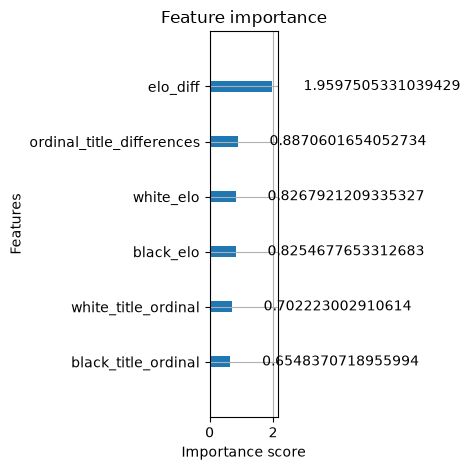

In [45]:
xgb.plot_importance(model, importance_type="gain", max_num_features=20)
plt.tight_layout()
plt.show()

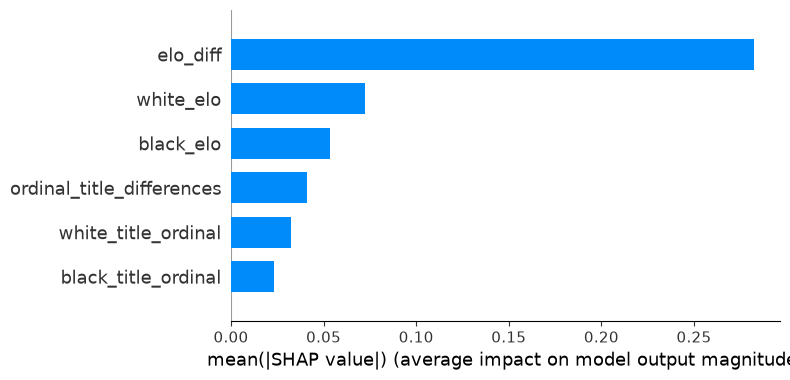

In [46]:
import shap

explainer = shap.TreeExplainer(model, model_output="raw")
shap_values = explainer.shap_values(X_test)  # shape (n_samples, n_features, n_classes)

# Overall importance = mean |SHAP| averaged across the three outcome classes.
shap.summary_plot(np.abs(shap_values).mean(axis=2), X_test, plot_type="bar")

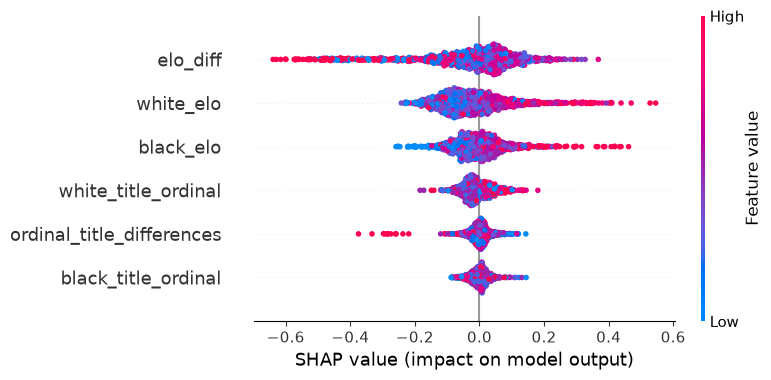

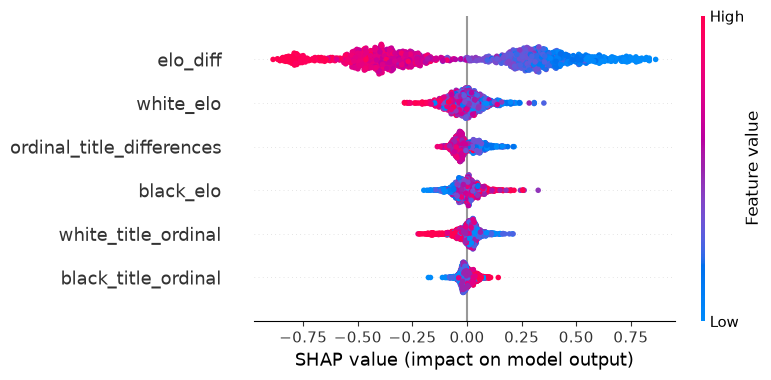

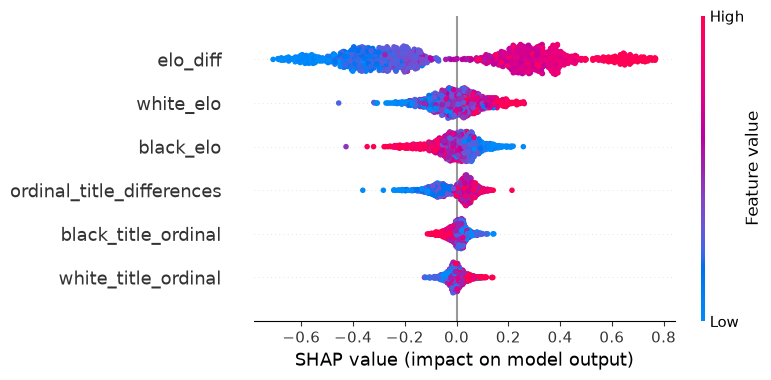

In [47]:
# le.classes_ order is ['draw', 'loss', 'win'] -> class 0/1/2 below.
shap.summary_plot(shap_values[:, :, 0], X_test)  # draw
shap.summary_plot(shap_values[:, :, 1], X_test)  # loss
shap.summary_plot(shap_values[:, :, 2], X_test)  # win

### 5.4 A small neural network (MLP)

A `(25, 50, 25)` MLP is the flexibility check. It nudges *accuracy* a touch above
XGBoost — but look at its confusion matrix: it predicts **zero draws**. The extra
capacity buys nothing on the rare class; it just commits harder to win/loss.

In [48]:
mlp = MLPClassifier(hidden_layer_sizes=(25, 50, 25), max_iter=10_000, random_state=42)
mlp.fit(X_train, y_train)

print("MLP Accuracy:", accuracy_score(y_test, mlp.predict(X_test)))
print("MLP Confusion Matrix (order draw/loss/win):\n",
      confusion_matrix(y_test, mlp.predict(X_test)))
evaluate("MLP", mlp.predict_proba(X_test), le.classes_)

MLP Accuracy: 0.6632373113854595
MLP Confusion Matrix (order draw/loss/win):
 [[  0  58  80]
 [  0 416 186]
 [  0 167 551]]


{'accuracy': 0.6632373113854595,
 'RPS': np.float64(0.20718635644882033),
 'log_loss': np.float64(1.7129315102689433),
 'AUC_draw': 0.49851229688186205}

### 5.5 Bake-off takeaways

- **A hard ~66% ceiling.** Every model — from Naive Bayes to a tuned neural net —
  lands in the same narrow accuracy band. The signal lives almost entirely in the
  rating gap, and once you've used it, you're done.
- **Draws are nigh-impossible.** AUC for P(draw) hovers around **0.5** for every
  model; the strongest models predict *almost no* draws because, given the
  features, draw is never the single most likely outcome. The EDA in §3.2 already
  told us why: draws have no distinctive location in feature space.
- **We settled on XGBoost** as the front-runner among the *flexible* learners — a
  whisker off the best proper-scoring-rule numbers, with well-calibrated win/loss
  probabilities and uniquely SHAP-interpretable feature attribution, and on par
  with the MLP on accuracy (but far better calibrated — note the MLP's inflated
  log loss from over-confident, all-or-nothing predictions).
- **Simple already keeps pace.** A plain logistic regression matches XGBoost on
  these scores. That's the real lesson of the bake-off: with only rating- and

  title-based signal to extract, model *complexity* buys almost nothing.that is also calibrated, uncertainty-aware, and updatable in `O(1)`?**

models already match the black boxes, **can we get the same accuracy from something
That sets up the question we take seriously in the next part: if simple, transparent

## 6. A Bayesian alternative — the Dirichlet-Multinomial "smart counting" model

> **For readers new to Bayesian methods:** don't be put off by the name. The
> model in this part is, at heart, **counting** — how often White wins, draws,
> and loses among similar games — with one principled fix for the buckets that
> are too small to trust. Every term is defined before it's used.

### 6.0 What this model does, in plain language

We sort games into a handful of look-alike buckets ("strata"), defined by the
**rating gap** and the **title gap** between the two players. Then, *within each
bucket*, we simply **count** how often White wins, draws, and loses. The only
twist over naive counting is a principled way to handle thin buckets: a shared
**prior** — a default belief, learned from the data itself — that gently pulls a
sparse bucket's estimate toward the global picture until that bucket has seen
enough games to speak for itself. That's the whole model. No gradient descent, no
sampling — the answer is a closed-form fraction.

### Why bother doing it the Bayesian way?

- **It's principled, not ad-hoc.** "Smooth the counts a bit so small buckets
  aren't crazy" is a hack everyone reinvents. Bayesian probability is the *unique*
  calculus consistent with a short list of common-sense axioms (Cox's theorem) for
  reasoning under uncertainty. Our smoothing isn't a knob we tuned — it falls out
  of writing the model down honestly. The amount of smoothing is **derived**.
- **Computation is trivial.** The Dirichlet distribution is **conjugate** to the
  Multinomial, meaning the updated belief has the same form as the prior, and
  updating is literally *vector addition* — `posterior = prior + counts`. Adding a
  new game is `O(1)`: increment one count. No refitting, ever.
- **Every number is interpretable.** `α` is "how many pseudo-games the prior is
  worth," `m` is "the prior's outcome split," and each prediction is a fraction
  you could compute by hand. Contrast that with the hundreds of opaque split
  points inside a boosted-tree ensemble.
- **Uncertainty is free.** Because we carry a full posterior *distribution* (not a
  single point estimate), credible intervals come out analytically — no bootstrap.

### The model, in one line of math

$$
p_s \mid \alpha, m \sim \text{Dirichlet}(\alpha m), \qquad
n_s \mid p_s \sim \text{Multinomial}(N_s, p_s)
\;\;\Longrightarrow\;\;
p_s \mid \text{data} \sim \text{Dirichlet}(\alpha m + n_s)
$$

Read left to right: each stratum `s` has an unknown outcome split `p_s` (a point
on the triangle of loss/draw/win probabilities); we put a Dirichlet prior on it;
we observe that stratum's counts `n_s`; and — thanks to conjugacy — the updated
belief is *again a Dirichlet*, with the prior's pseudo-counts `αm` simply **added**
to the observed counts. `(α, m)` are fit by **empirical Bayes** (let the data pick
the prior); everything below is closed-form arithmetic.

### 6.1 The variables — same six features, used differently

The Bayesian model uses the **same six leakage-safe features** as the bake-off,
but instead of feeding them to an algorithm it **bins two "gap" features** and
counts within each bin:

- **win/loss axis** — `elo_diff` = `white_elo − black_elo`, cut into **5 quantile
  bins**.
- **title axis** — `ordinal_title_differences` = `white_title_ordinal −
  black_title_ordinal`, cut into **3 quantile bins**.

That makes a `5 × 3` grid of up to 15 strata. **Why bin instead of fitting a
curve?** Binning is *non-parametric*: we never assume the relationship is linear
or logistic or any particular shape — the data draws its own response surface. The
cost is needing enough games per bin, which is exactly what the prior fixes.

### 6.2 Stratify — sort each game into a bucket

A stratum is one cell of the `(elo_diff bin) × (title_diff bin)` grid. We use
**quantile** bins (`pd.qcut`) so each bin holds a comparable *number of games*
(not a comparable width), keeping buckets populated. Two details matter for an
honest hold-out:

- If edges are supplied, we **reuse the train-derived cutpoints** on the test set
  — computing test bins from test data would peek at the future.
- The outer edges are opened to `±∞` so an out-of-range test value lands in the
  nearest bucket instead of becoming `NaN`.

In [49]:
def assign_strata(df, elo_diff_edges=None, title_diff_edges=None,
                   n_elo_diff_bins=5, n_title_diff_bins=3):
    out = df.copy()

    if elo_diff_edges is None:
        _, elo_diff_edges = pd.qcut(df["elo_diff"], n_elo_diff_bins,
                                     retbins=True, duplicates="drop")
    if title_diff_edges is None:
        _, title_diff_edges = pd.qcut(df["ordinal_title_differences"], n_title_diff_bins,
                                       retbins=True, duplicates="drop")

    elo_diff_edges = np.asarray(elo_diff_edges, dtype=float).copy()
    title_diff_edges = np.asarray(title_diff_edges, dtype=float).copy()
    elo_diff_edges[0], elo_diff_edges[-1] = -np.inf, np.inf
    title_diff_edges[0], title_diff_edges[-1] = -np.inf, np.inf

    ed_bin = pd.cut(out["elo_diff"], elo_diff_edges, labels=False, include_lowest=True)
    td_bin = pd.cut(out["ordinal_title_differences"], title_diff_edges, labels=False, include_lowest=True)

    out["stratum"] = (ed_bin.astype(str) + "_" + td_bin.astype(str))

    edges = dict(elo_diff_edges=elo_diff_edges, title_diff_edges=title_diff_edges)
    return out, edges

### 6.3 Count table

For each stratum, tally how many games ended in loss / draw / win. These per-bucket
counts `n_s` are the *only* thing the model learns from.

In [50]:
def build_count_table(df):
    """Return (strata_labels, counts[n_strata x 3]) with columns ordered as OUTCOMES."""
    counts = (df.groupby("stratum")["outcome"]
                .value_counts()
                .unstack(fill_value=0)
                .reindex(columns=OUTCOMES, fill_value=0))
    return counts.index.tolist(), counts.values.astype(float)

### 6.4 Empirical-Bayes fit of `(α, m)` — letting the data choose the prior

**Empirical Bayes = "let the data choose the prior."** A purist sets the prior by
hand before seeing data; empirical Bayes instead picks the `(α, m)` that makes the
*observed counts across all strata* as likely as possible. It's why our smoothing
strength is **learned, not hand-tuned**.

The trick that makes this cheap: because the Dirichlet is conjugate to the
Multinomial, we can **integrate `p_s` out analytically**. Each stratum's counts
then follow a Dirichlet-Multinomial distribution depending *only* on `(α, m)`:

$$
n_s \sim \text{DirichletMultinomial}(N_s,\, \alpha m),
\qquad
(\hat\alpha, \hat m) = \arg\max_{\alpha, m} \sum_s \log P(n_s \mid \alpha, m).
$$

So we never sample the per-stratum probabilities — they're marginalized away,
leaving a tiny 3-parameter optimization. **Intuition:** a *large* `α̂` means strata
look alike (pool aggressively); a *small* `α̂` means strata genuinely differ (trust
each bucket's own counts). We optimize unconstrained via `α = exp(log_alpha)` and
`m = softmax(z)`.

In [51]:
def dirichlet_multinomial_loglik(alpha, m, counts):
    a = alpha * m              # concentration vector, shape (K,)
    N = counts.sum(axis=1)      # total games per stratum
    A = a.sum()                  # == alpha

    term1 = gammaln(N + 1) - gammaln(counts + 1).sum(axis=1)
    term2 = gammaln(A) - gammaln(A + N)
    term3 = (gammaln(a[None, :] + counts) - gammaln(a[None, :])).sum(axis=1)
    return (term1 + term2 + term3).sum()


def fit_hyperparameters(counts, m_init=None, alpha_init=10.0):
    K = counts.shape[1]
    if m_init is None:
        m_init = counts.sum(axis=0) / counts.sum()  # global outcome frequencies

    z_init = np.log(np.clip(m_init[:-1], 1e-6, None) / np.clip(m_init[-1], 1e-6, None))
    x0 = np.concatenate([[np.log(alpha_init)], z_init])

    def neg_loglik(x):
        log_alpha = x[0]
        z = np.concatenate([x[1:], [0.0]])
        m = softmax(z)
        return -dirichlet_multinomial_loglik(np.exp(log_alpha), m, counts)

    res = minimize(neg_loglik, x0, method="L-BFGS-B")
    log_alpha = res.x[0]
    z = np.concatenate([res.x[1:], [0.0]])
    m = softmax(z)
    alpha = float(np.exp(log_alpha))
    return alpha, m, res

### 6.5 Posterior predictive — where conjugacy pays off

For each stratum: `p_s | data ~ Dirichlet(αm + n_s)` — the posterior is **the
prior's pseudo-counts plus the observed counts**, nothing more. The point estimate
is just a fraction:

$$
\mathbb{E}[p_s \mid \text{data}] = \dfrac{\alpha m + n_s}{\alpha + N_s}.
$$

Read it as a **precision-weighted average**: it blends the prior mean `m` with the
empirical frequency `n_s / N_s`, weighted by `α` (pseudo-games) and `N_s` (real
games). A thin stratum leans on the prior; a fat one is essentially its raw rate.
This *is* the shrinkage — and it costs one vector addition, the promised `O(1)`
update. Credible intervals for any single outcome come from the Dirichlet's Beta
marginals, so uncertainty bands are exact and **free**.

In [52]:
def posterior_predictive(counts, alpha, m):
    a = alpha * m
    N = counts.sum(axis=1, keepdims=True)
    posterior_alpha = a[None, :] + counts
    p_hat = posterior_alpha / (alpha + N)
    return p_hat, posterior_alpha


def credible_interval(posterior_alpha_row, k, level=0.90):
    from scipy.stats import beta
    a_k = posterior_alpha_row[k]
    a_rest = posterior_alpha_row.sum() - a_k
    lo, hi = beta.ppf([(1 - level) / 2, 1 - (1 - level) / 2], a_k, a_rest)
    return lo, hi


def predict(new_df, edges, p_hat_lookup, m):
    binned, _ = assign_strata(new_df,
                               elo_diff_edges=edges["elo_diff_edges"],
                               title_diff_edges=edges["title_diff_edges"])
    probs = np.array([p_hat_lookup.get(s, m) for s in binned["stratum"]])
    return probs, binned["stratum"]

### 6.6 Metrics

We score *probabilities*, not just the top guess, using the same two **proper
scoring rules** defined in Setup — **RPS** (for the ordered outcome) and
**multiclass log loss**. Both are minimized by reporting your true beliefs, so they
can't be gamed by over- or under-confidence. (The functions are already defined
above; we reuse them here so the Bayesian model is scored identically to the
bake-off.)

### 6.7 Fit the model

We reuse the exact `train`/`test` split from Part 2 — train on every event up to
April 7, test on the held-out April 14 tournament.

In [53]:
train_binned, edges = assign_strata(train, n_elo_diff_bins=5, n_title_diff_bins=3)
strata_labels, counts = build_count_table(train_binned)

alpha, m, opt_res = fit_hyperparameters(counts)

print(f"Fitted alpha (prior strength, in 'pseudo-games') = {alpha:.2f}")
print(f"Fitted m     (prior outcome distribution)        = {dict(zip(OUTCOMES, np.round(m, 3)))}")
print(f"n strata = {len(strata_labels)}")
print(f"mean stratum size = {counts.sum(axis=1).mean():.1f}")
print(f"min stratum size  = {counts.sum(axis=1).min():.0f}")

p_hat, post_alpha = posterior_predictive(counts, alpha, m)
p_hat_lookup = dict(zip(strata_labels, p_hat))

N = counts.sum(axis=1)
empirical = counts / N[:, None]

Fitted alpha (prior strength, in 'pseudo-games') = 8.40
Fitted m     (prior outcome distribution)        = {'loss': np.float64(0.393), 'draw': np.float64(0.138), 'win': np.float64(0.469)}
n strata = 15
mean stratum size = 704.9
min stratum size  = 37


#### Interpreting `α` and `m`

A fitted **`α ≈ 8`** pseudo-games is *small* next to stratum sizes that run from a
few dozen to several hundred games. Since the posterior mean weights prior vs. data
as `α : N_s`, a prior worth ~8 games is swamped almost everywhere — **the data
dominates, and shrinkage is light**, doing real stabilizing work only in the
thinnest cells. The valuable part is that this strength was *learned* from the
marginal likelihood, not picked by hand: a **derived** regularization strength.

`m` is the prior's mean outcome split — the target every stratum is shrunk
*toward*. Its draw entry comes out a touch *higher* than the raw overall draw rate;
with `α` this small the marginal likelihood is only weakly sensitive to `m`, so
don't over-read it as *the* draw rate. The next plot makes that explicit.

### 6.8 Visualization 1 — prior mean vs. global empirical frequency

Blue bars are the raw outcome frequencies across the whole training set; orange
bars are the fitted prior mean `m`. Loss and win line up closely (the prior is
sensible on the common classes); the draw bar sits a little above the empirical
rate — the mild small-`α` upward bias discussed above.

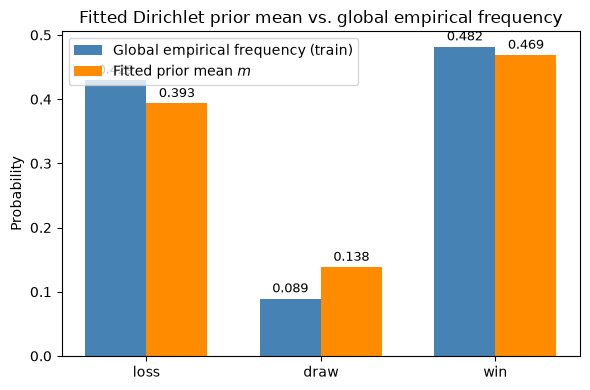

In [54]:
global_empirical = train["outcome"].value_counts(normalize=True).reindex(OUTCOMES).values

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(OUTCOMES))
width = 0.35
ax.bar(x - width/2, global_empirical, width, label="Global empirical frequency (train)", color="steelblue")
ax.bar(x + width/2, m, width, label="Fitted prior mean $m$", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(OUTCOMES)
ax.set_ylabel("Probability")
ax.set_title("Fitted Dirichlet prior mean vs. global empirical frequency")
for i, (g, mm) in enumerate(zip(global_empirical, m)):
    ax.text(i - width/2, g + 0.01, f"{g:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, mm + 0.01, f"{mm:.3f}", ha="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

### 6.9 Visualization 2 — shrinkage in action

Each blue dot is a stratum's raw frequency; the orange dot is its shrunk posterior
mean; the gray segment is how far shrinkage moved it; the dashed line is the prior
mean `m`. The segments are short and shrink toward zero as stratum size `N_s` grows
— the visual confirmation that "`α ≈ 8` is swamped by the data." Only the smallest
strata get a visible tug toward the prior.

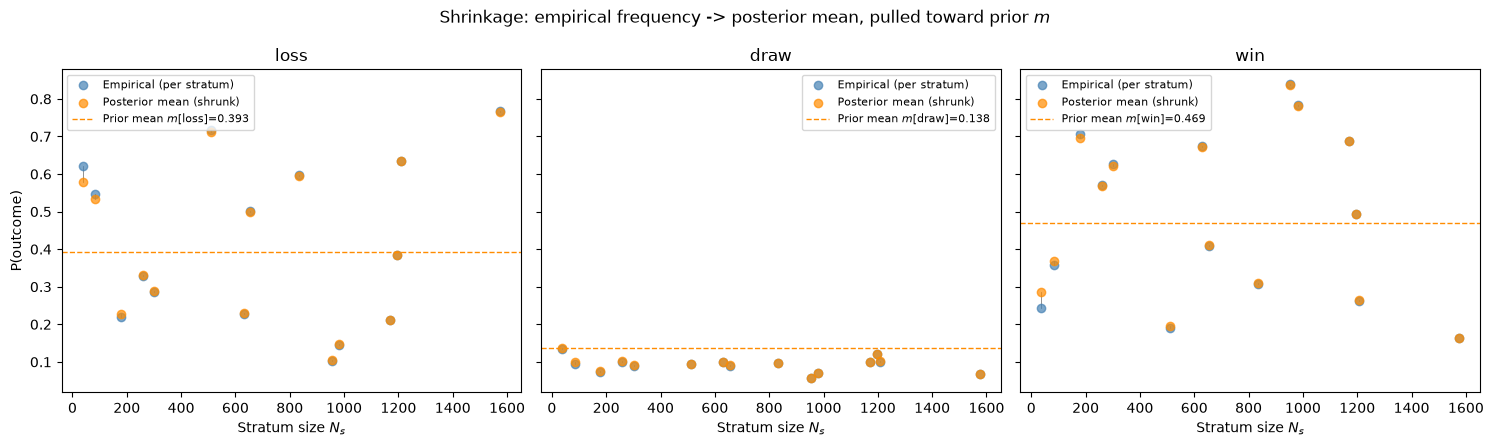

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for k, outcome in enumerate(OUTCOMES):
    ax = axes[k]
    order = np.argsort(N)
    ax.scatter(N[order], empirical[order, k], label="Empirical (per stratum)",
               alpha=0.7, color="steelblue", zorder=2)
    ax.scatter(N[order], p_hat[order, k], label="Posterior mean (shrunk)",
               alpha=0.7, color="darkorange", zorder=2)
    for i in order:
        ax.plot([N[i], N[i]], [empirical[i, k], p_hat[i, k]], color="gray", lw=0.6, zorder=1)
    ax.axhline(m[k], color="darkorange", ls="--", lw=1, label=f"Prior mean $m$[{outcome}]={m[k]:.3f}")
    ax.set_title(outcome)
    ax.set_xlabel("Stratum size $N_s$")
    if k == 0:
        ax.set_ylabel("P(outcome)")
    ax.legend(fontsize=8)
plt.suptitle("Shrinkage: empirical frequency -> posterior mean, pulled toward prior $m$")
plt.tight_layout()
plt.show()

### 6.10 Visualization 3 — posterior P(draw) per stratum, with 90% credible intervals

Each row is a stratum: the orange dot is its posterior `P(draw)`, the gray bar its
90% credible interval (analytic, straight from the Dirichlet's Beta marginal). Two
things at once: the point estimates span only a narrow, low band, **and** the
intervals are wide and heavily overlapping. That combination *is* "draws are nearly
unpredictable here" — strata barely separate on `P(draw)` relative to their own
uncertainty, foreshadowing the AUC ≈ 0.5 below.

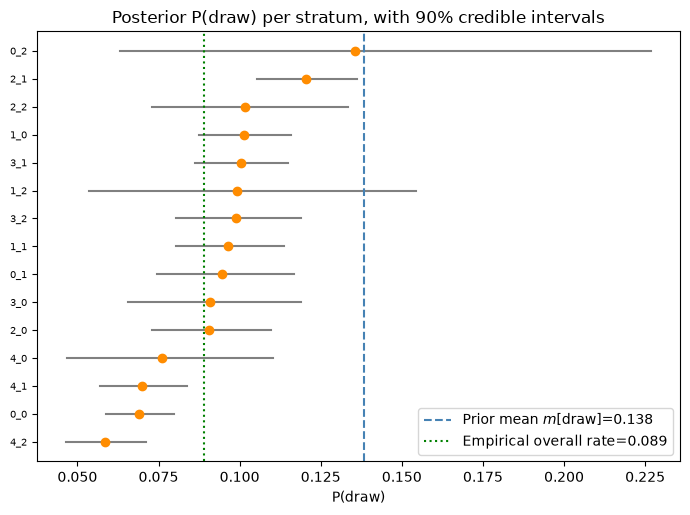

In [56]:
draw_idx = OUTCOMES.index("draw")
order = np.argsort(p_hat[:, draw_idx])

fig, ax = plt.subplots(figsize=(7, max(4, 0.35 * len(strata_labels))))
for rank, i in enumerate(order):
    lo, hi = credible_interval(post_alpha[i], draw_idx)
    mean = p_hat[i, draw_idx]
    ax.plot([lo, hi], [rank, rank], color="gray", lw=1.5, zorder=1)
    ax.plot(mean, rank, "o", color="darkorange", zorder=2)

ax.axvline(m[draw_idx], color="steelblue", ls="--", label=f"Prior mean $m$[draw]={m[draw_idx]:.3f}")
global_draw_rate = train["outcome"].eq("draw").mean()
ax.axvline(global_draw_rate, color="green", ls=":", label=f"Empirical overall rate={global_draw_rate:.3f}")

ax.set_yticks(range(len(strata_labels)))
ax.set_yticklabels([strata_labels[i] for i in order], fontsize=7)
ax.set_xlabel("P(draw)")
ax.set_title("Posterior P(draw) per stratum, with 90% credible intervals")
ax.legend()
plt.tight_layout()
plt.show()

### 6.11 Visualization 4 — P(draw) across the stratification grid

Columns are `elo_diff` bins (0 = White underdog … 4 = White favorite); rows are
`ordinal_title_differences` bins. If draws were predictable we'd see a clear
gradient — a row or column where draws spike. Instead the values stay in a tight,
low range with no clean pattern across either axis.

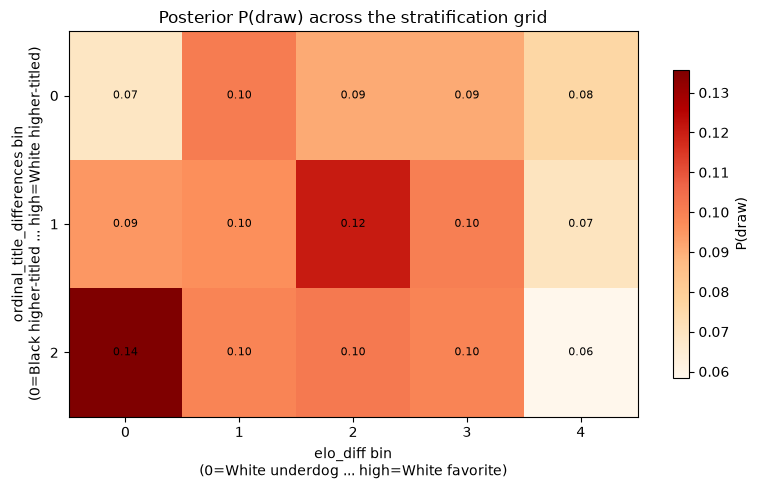

In [57]:
strata_df = pd.DataFrame({"stratum": strata_labels, "p_draw": p_hat[:, draw_idx], "N": N})
parts = strata_df["stratum"].str.split("_", expand=True).astype(int)
strata_df["ed_bin"], strata_df["td_bin"] = parts[0], parts[1]

fig, ax = plt.subplots(figsize=(8, 5))

pivot = strata_df.pivot(index="td_bin", columns="ed_bin", values="p_draw")
pivot = pivot.reindex(index=range(strata_df["td_bin"].max() + 1),
                       columns=range(strata_df["ed_bin"].max() + 1))
im = ax.imshow(pivot.values, cmap="OrRd",
               vmin=p_hat[:, draw_idx].min(), vmax=p_hat[:, draw_idx].max(), aspect="auto")
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("elo_diff bin\n(0=White underdog ... high=White favorite)")
ax.set_ylabel("ordinal_title_differences bin\n(0=Black higher-titled ... high=White higher-titled)")
ax.set_title("Posterior P(draw) across the stratification grid")
for (i, j), val in np.ndenumerate(pivot.values):
    if not np.isnan(val):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="P(draw)", shrink=0.8)
plt.tight_layout()
plt.show()

### 6.12 Evaluation on the held-out tournament

Compared against the naive baseline that assigns every game the global
training-set outcome frequencies (no covariates at all) — the bar to clear. The
model improves on **both** proper scoring rules; the lift comes almost entirely
from the `elo_diff` axis sharpening the win/loss split (the draw axis contributes
little, as every diagnostic keeps confirming).

In [58]:
test_probs, test_strata = predict(test, edges, p_hat_lookup, m)
y_true = test["outcome"].map({o: i for i, o in enumerate(OUTCOMES)}).values

held_out_rps = rps(test_probs, y_true).mean()
held_out_ll = multiclass_log_loss(test_probs, y_true).mean()

global_probs = np.tile(
    train["outcome"].value_counts(normalize=True).reindex(OUTCOMES).values,
    (len(test), 1)
)
baseline_rps = rps(global_probs, y_true).mean()
baseline_ll = multiclass_log_loss(global_probs, y_true).mean()

print(f"Held-out RPS:      {held_out_rps:.4f}   (global-frequency baseline: {baseline_rps:.4f})")
print(f"Held-out log loss: {held_out_ll:.4f}   (global-frequency baseline: {baseline_ll:.4f})")

Held-out RPS:      0.1979   (global-frequency baseline: 0.2464)
Held-out log loss: 0.8243   (global-frequency baseline: 0.9378)


#### Confusion matrix and per-class report (argmax decision)

In [59]:
y_pred = test_probs.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
display(pd.DataFrame(cm,
                      index=[f"true_{o}" for o in OUTCOMES],
                      columns=[f"pred_{o}" for o in OUTCOMES]))
print(classification_report(y_true, y_pred, target_names=OUTCOMES, zero_division=0))

,pred_loss,pred_draw,pred_win
true_loss,426,0,176
true_draw,62,0,76
true_win,176,0,542


              precision    recall  f1-score   support

        loss       0.64      0.71      0.67       602
        draw       0.00      0.00      0.00       138
         win       0.68      0.75      0.72       718

    accuracy                           0.66      1458
   macro avg       0.44      0.49      0.46      1458
weighted avg       0.60      0.66      0.63      1458



#### A note on draw recall

`pred_draw` will likely be an all-zero column — no stratum's posterior mean ever
makes draw the *most likely* outcome (all are well under 1/3). **This is the
mathematically correct behavior of a calibrated model:** argmax-ing to "draw"
would be wrong more often than right in every stratum. Accuracy is the wrong lens
for the rare class; the right question is whether `P(draw)` is *informative* (a
ranking question), which the AUC below addresses.

In [60]:
is_draw_true = (y_true == draw_idx).astype(int)
p_draw_test = test_probs[:, draw_idx]
auc = roc_auc_score(is_draw_true, p_draw_test)
print(f"AUC for P(draw) discriminating draw vs. non-draw: {auc:.3f}")

AUC for P(draw) discriminating draw vs. non-draw: 0.537


### 6.13 Visualization 5 — calibration / reliability diagrams

For each outcome, bin predictions by predicted probability and compare to the
observed frequency. On the diagonal means "when we say 30%, it happens ~30% of the
time." Loss and win track the diagonal well — the win/loss probabilities are
*trustworthy*, not merely discriminative. Draw points cluster at low predicted
probabilities and are noisier, as expected for a rare, low-signal class.

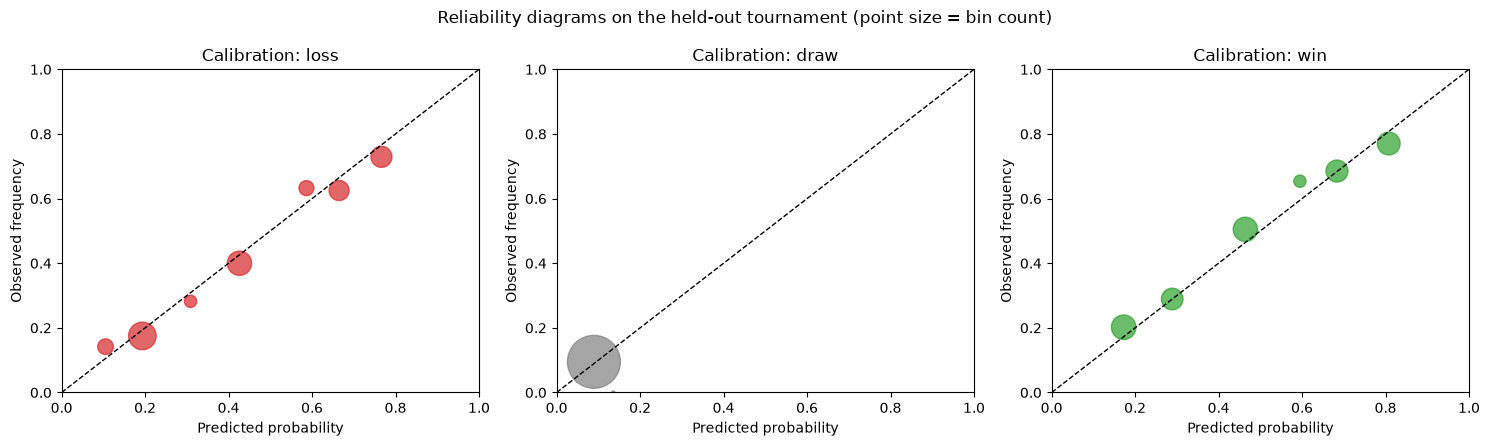

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
n_bins = 8
bins = np.linspace(0, 1, n_bins + 1)

for k, outcome in enumerate(OUTCOMES):
    ax = axes[k]
    probs_k = test_probs[:, k]
    true_k = (y_true == k).astype(int)
    bin_ids = np.clip(np.digitize(probs_k, bins) - 1, 0, n_bins - 1)

    pred_means, obs_means, counts_ = [], [], []
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() > 0:
            pred_means.append(probs_k[mask].mean())
            obs_means.append(true_k[mask].mean())
            counts_.append(mask.sum())

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.scatter(pred_means, obs_means, s=np.array(counts_), color=OUTCOME_COLORS[outcome], alpha=0.7)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(f"Calibration: {outcome}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle("Reliability diagrams on the held-out tournament (point size = bin count)")
plt.tight_layout()
plt.show()

### 6.14 Diagnostic — does a richer feature set discriminate draws any better?

A logistic regression on the *continuous* (unbinned) versions of the same six
features. We compare its **train** AUC to its **held-out** AUC: a large gap would
signal overfitting on the rare class. Instead both come out ≈ 0.55 — essentially
equal, and barely above the 0.5 coin-flip line. The *absence* of a train/test gap
rules out overfitting: the model isn't memorizing noise, **the signal simply isn't
there**. A negative result, honestly reported, is still a result.

In [62]:
def draw_feature_frame(d):
    return pd.DataFrame({
        "white_elo": d["white_elo"],
        "black_elo": d["black_elo"],
        "elo_diff": d["elo_diff"],
        "white_title_ordinal": d["white_title_ordinal"].fillna(0),
        "black_title_ordinal": d["black_title_ordinal"].fillna(0),
        "ordinal_title_differences": d["ordinal_title_differences"],
    })

draw_features_train = draw_feature_frame(train)
draw_features_test = draw_feature_frame(test)

medians = draw_features_train.median()
is_draw_train = (train["outcome"] == "draw").astype(int)
is_draw_test = (test["outcome"] == "draw").astype(int)

scaler = StandardScaler().fit(draw_features_train.fillna(medians))
Xtr_draw = scaler.transform(draw_features_train.fillna(medians))
Xte_draw = scaler.transform(draw_features_test.fillna(medians))

clf = LogisticRegression(max_iter=1000).fit(Xtr_draw, is_draw_train)

train_auc = roc_auc_score(is_draw_train, clf.predict_proba(Xtr_draw)[:, 1])
test_auc = roc_auc_score(is_draw_test, clf.predict_proba(Xte_draw)[:, 1])

print(f"Train AUC: {train_auc:.3f}")
print(f"Test  AUC: {test_auc:.3f}")
print(dict(zip(draw_features_train.columns, clf.coef_[0].round(3))))

Train AUC: 0.549
Test  AUC: 0.551
{'white_elo': np.float64(0.121), 'black_elo': np.float64(0.147), 'elo_diff': np.float64(-0.025), 'white_title_ordinal': np.float64(-0.029), 'black_title_ordinal': np.float64(-0.031), 'ordinal_title_differences': np.float64(0.002)}


### 6.15 Empirical-Bayes prior vs. uninformative priors

We *learned* the prior `(α, m)`. Was it worth it? The classic alternatives are
**uninformative priors** — fixed, data-free defaults:

| prior | `αm` (pseudo-counts) | `α` | mean `m` | idea |
|---|---|---|---|---|
| **Empirical Bayes** (ours) | fitted | ≈ 8 | fitted, draw-tilted | let the data choose the prior |
| **Laplace** ("add-one") | (1, 1, 1) | 3 | uniform | every outcome starts with one phantom game |
| **Jeffreys** | (½, ½, ½) | 1.5 | uniform | the invariant "objective" default |
| **MLE / raw counts** | (0, 0, 0) | → 0 | — | no prior; pure empirical frequencies |

**The trade-offs.** Uninformative priors assume a *flat* mean (`m = 1/3` each),
which for chess is a genuinely bad guess (it implies draws are as likely as wins).
EB shrinks toward the realistic, data-derived split instead. They also fix the
*strength* arbitrarily, whereas EB tunes `α` to how much strata actually differ.
MLE is fine until a bucket is thin — a stratum that saw zero draws would assign
`P(draw)=0`, infinitely confident and infinitely punished by log loss the moment a
draw appears; the prior is the insurance. **Honest caveat for this dataset:** our
strata are large relative to every prior's `α`, so all four methods converge to
similar held-out scores. The point isn't a big EB win *here* — it's that EB gives
the *right* default (sensible mean, learned strength) for free, an advantage that
grows precisely as data gets sparse. The cell below quantifies it.

In [63]:
uniform_m = np.ones(len(OUTCOMES)) / len(OUTCOMES)

prior_specs = [
    (alpha, m, "Empirical Bayes (fitted)"),
    (3.0, uniform_m, "Laplace / flat Dir(1,1,1)"),
    (1.5, uniform_m, "Jeffreys Dir(0.5)"),
    (1e-9, uniform_m, "MLE / raw counts (alpha->0)"),
]


def evaluate_prior(alpha_p, m_p):
    """Posterior under a given prior, scored on the held-out tournament."""
    p_hat_p, _ = posterior_predictive(counts, alpha_p, m_p)
    lookup = dict(zip(strata_labels, p_hat_p))
    probs, _ = predict(test, edges, lookup, m_p)
    return rps(probs, y_true).mean(), multiclass_log_loss(probs, y_true).mean()


rows = []
for alpha_p, m_p, label in prior_specs:
    held_rps, held_ll = evaluate_prior(alpha_p, m_p)
    rows.append({"prior": label, "alpha": alpha_p,
                 "m_draw": m_p[OUTCOMES.index("draw")],
                 "held_out_RPS": held_rps, "held_out_log_loss": held_ll})

prior_results = pd.DataFrame(rows)
display(prior_results.round(4))

smallest = int(np.argmin(N))
print(f"\nSmallest stratum '{strata_labels[smallest]}': "
      f"N={N[smallest]:.0f}, counts(loss/draw/win)={counts[smallest].astype(int)}")
print(f"  {'empirical (no smoothing)':32s} = {np.round(empirical[smallest], 3)}")
for alpha_p, m_p, label in prior_specs:
    p_hat_p, _ = posterior_predictive(counts, alpha_p, m_p)
    print(f"  {label:32s} = {np.round(p_hat_p[smallest], 3)}")

,prior,alpha,m_draw,held_out_RPS,held_out_log_loss
0,Empirical Bayes (fitted),8.3979,0.1382,0.1979,0.8243
1,"Laplace / flat Dir(1,1,1)",3.0000,0.3333,0.1979,0.8244
2,Jeffreys Dir(0.5),1.5000,0.3333,0.1979,0.8243
3,MLE / raw counts (alpha->0),0.0000,0.3333,0.1979,0.8243



Smallest stratum '0_2': N=37, counts(loss/draw/win)=[23  5  9]
  empirical (no smoothing)         = [0.622 0.135 0.243]
  Empirical Bayes (fitted)         = [0.579 0.136 0.285]
  Laplace / flat Dir(1,1,1)        = [0.6  0.15 0.25]
  Jeffreys Dir(0.5)                = [0.61  0.143 0.247]
  MLE / raw counts (alpha->0)      = [0.622 0.135 0.243]


### 6.16 Why this Bayesian model is worth keeping

On the same forward-in-time hold-out, this fully closed-form counting model is
**competitive with — and on log loss/accuracy a hair ahead of — the tuned
XGBoost**, and on par with the MLP (the next section puts them side by side). It
earns that while being:

- **Interpretable** — every prediction is a fraction you can derive by hand; every
  parameter is chess-meaningful.
- **Conjugate / `O(1)` to update** — a new game is one vector addition: no
  retraining, no gradient steps, instant updates on the sufficient statistics
  (the per-stratum counts).
- **Principled** — the shrinkage is *derived* from the axioms of Bayesian
  probability, not a hand-tuned smoothing knob.
- **Honest about uncertainty** — analytic credible intervals, no bootstrap.

And it agrees with every other model on the hard truth: **draws are near-random**
under these features (overlapping credible intervals, a flat grid, held-out
`P(draw)` AUC ≈ 0.5, and no train/test gap in the diagnostic regression).

## 7. Head-to-head — every model on one scoreboard

All models scored on the **same held-out tournament**, the **same six features**,
and the **same metrics** (RPS and log loss in the natural `loss < draw < win`
order; lower is better). The Bayesian model is registered through the *identical*
evaluator as the rest, so this really is apples-to-apples.

In [64]:
# Register the Bayesian model on the SAME footing as every other model.
evaluate("Dirichlet-Multinomial (Bayesian)", test_probs, OUTCOMES)

comparison = (pd.DataFrame(model_scores).T
              [["accuracy", "RPS", "log_loss", "AUC_draw"]]
              .sort_values("log_loss"))
comparison.round(4)

,accuracy,RPS,log_loss,AUC_draw
Logistic Regression,0.6632,0.1953,0.8148,0.5577
Dirichlet-Multinomial (Bayesian),0.6639,0.1979,0.8243,0.5372
XGBoost,0.6516,0.2059,0.8675,0.5294
Naive Bayes,0.6557,0.2228,0.9863,0.5401
Random Forest,0.6296,0.2173,1.0417,0.5230
MLP,0.6632,0.2072,1.7129,0.4985
Linear Regression (-1/0/1),0.3224,NaN,NaN,NaN


**Reading the table.** Accuracy clusters in a tight band around ~0.63–0.66 for
every serious model — the ceiling we kept hitting. On the probabilistic scores the
standouts are actually the two most *interpretable* models: **Logistic Regression**
and the **Dirichlet-Multinomial** post the lowest log loss and RPS, with **XGBoost**
a close third. The **MLP** ties on accuracy but is punished hard on log loss for
over-confident predictions, and **Random Forest** trails. `AUC_draw ≈ 0.5`
everywhere is the recurring verdict on draws. The ordinal linear regression is the
cautionary tale — forcing an ordered category onto one line collapses its accuracy
and yields no usable probabilities.


**The headline:** the flexible black boxes win *nothing* here — a plain logisticand updatable in `O(1)` as new games stream in.

regression and a closed-form Bayesian counting model match or beat them. Andengineering choice: equally interpretable, but also calibrated, uncertainty-aware,
between those two front-runners, the Dirichlet-Multinomial is the better

## 8. Where this goes next — per-player AI agents from PGNs

Every model here treats a game as a function of two *numbers per player* (rating
and title). That's why they all plateau: two scalars can't capture *how* a given
player actually plays. The natural next step is to model **players, not just
ratings**.

The idea: build a profile — an actual **AI agent** (not an LLM, but a learned
behavioral model) — for each player from their game records (PGNs). Such an agent
would encode opening repertoire, tactical vs. positional tendency, time-trouble
behavior, risk appetite, and how those shift against stronger or weaker opponents.
The raw material is already partly in the pipeline: `build_dataset.py` parses
per-player behavioral stats, and full PGNs are available from the same Chess.com
API we crawled.

Inference then changes shape entirely. Instead of mapping a feature vector to a
probability, you would **simulate the matchup** — pit player A's agent against
player B's agent (style versus style, repertoire versus repertoire) and read off
the outcome distribution from the encounter. That is also the most promising route
to the one thing every model in this notebook failed at: **predicting draws** — a
draw is often a property of *how two specific styles interact* (a solid repertoire
neutralizing an aggressive one), which is invisible to rating and title alone but
exactly what a style-aware agent could capture.